<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/INTRODU%C3%87%C3%83O_AOS_MODELOS_LINEARES_GENERALIZADOS_Lista_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Informações do Modelo**

Esta seção descreve a estrutura e os dados usados no modelo. É como o "cartão de identidade" da sua análise.

Parâmetro	Descrição
Dep. Variable:	A variável dependente (o que está sendo previsto).
No. Observations:	O número total de observações no seu conjunto de dados.
Model:	O tipo de modelo estatístico, neste caso, um Modelo Linear Generalizado (GLM).
Df Residuals:	Os graus de liberdade residuais.
Model Family:	A família de distribuição de probabilidade usada, que para contagens é a Poisson.
Df Model:	Os graus de liberdade do modelo (o número de variáveis preditoras).
Link Function:	A função que conecta a média da variável de resposta aos preditores. Para o modelo de Poisson, é a função logarítmica.
Scale:	Um parâmetro de dispersão. Para o Poisson, ele é fixo em 1.0.

# 2. Informações de Ajuste do Modelo
Esta seção avalia o quão bem o modelo se ajusta aos dados.

Parâmetro	Descrição
Method:	O método de otimização usado para estimar os coeficientes do modelo.
Log-Likelihood:	O logaritmo da verossimilhança. Valores maiores (mais próximos de zero) indicam um melhor ajuste do modelo.
Deviance:	Uma medida de discrepância entre o modelo ajustado e os dados. Uma deviance menor indica um ajuste melhor. A razão entre a Deviance e os graus de liberdade residuais é usada para checar a sobredispersão.
Pearson chi2:	Uma estatística alternativa à Deviance para avaliar o ajuste do modelo.
Pseudo R-squ.:	Uma versão do R-quadrado para modelos GLM. Não tem a mesma interpretação que o R-quadrado em regressões lineares, mas valores maiores geralmente indicam que o modelo explica mais variabilidade.

# 3. Tabela de Coeficientes
Esta é a parte central da saída, onde você pode interpretar a influência de cada variável no modelo.

Parâmetro	Descrição
coef:	O coeficiente de cada preditor. Representa o impacto na variável dependente. Por exemplo, um coeficiente de -0.5 para NAP significa que um aumento de uma unidade em NAP está associado a uma diminuição no log da riqueza de espécies.
std err:	O erro padrão do coeficiente.
z:	A estatística de teste z. É a razão entre o coeficiente e seu erro padrão.
P>|z|:	O valor-p. Se for menor que um nível de significância (geralmente 0.05), o coeficiente é considerado estatisticamente significativo, o que significa que o preditor tem um efeito real na variável dependente.
[0.025 - 0.975]:	O intervalo de confiança de 95% para o coeficiente. Se este intervalo não incluir o zero, o coeficiente é considerado estatisticamente significativo.

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns

# Conteúdo do arquivo fornecido pelo usuário
file_content = """
"Richness"	"Exposure"	"NAP"	"Beach"	"Site"
11	10	0.045	1	1
10	10	-1.036	1	2
13	10	-1.336	1	3
11	10	0.616	1	4
10	10	-0.684	1	5
8	8	1.19	2	1
9	8	0.82	2	2
8	8	0.635	2	3
19	8	0.061	2	4
17	8	-1.334	2	5
6	11	-0.976	3	1
1	11	1.494	3	2
4	11	-0.201	3	3
3	11	-0.482	3	4
3	11	0.167	3	5
1	11	1.768	4	1
3	11	-0.03	4	2
3	11	0.46	4	3
1	11	1.367	4	4
4	11	-0.811	4	5
3	10	1.117	5	1
22	10	-0.503	5	2
6	10	0.729	5	3
0	10	1.627	5	4
6	10	0.054	5	5
5	11	-0.578	6	1
4	11	-0.348	6	2
1	11	2.222	6	3
6	11	-0.893	6	4
4	11	0.766	6	5
2	11	0.883	7	1
1	11	1.786	7	2
1	11	1.375	7	3
3	11	-0.06	7	4
4	11	0.367	7	5
3	10	1.671	8	1
5	10	-0.375	8	2
7	10	-1.005	8	3
5	10	0.17	8	4
0	10	2.052	8	5
7	10	-0.356	9	1
11	10	0.094	9	2
3	10	-0.002	9	3
0	10	2.255	9	4
2	10	0.865	9	5
"""

# Salva o conteúdo em um arquivo para leitura
with open('RIKZ.txt', 'w') as f:
    f.write(file_content.strip())

# Lê os dados do arquivo
data = pd.read_csv('RIKZ.txt', sep='\t')

# Converte "Beach" para variável categórica, conforme solicitado
data['Beach'] = data['Beach'].astype('category')

print("## Análise de Regressão de Poisson\n")

# 1. Ajuste do modelo com interação usando GLM
print("### Ajustando o Modelo de Poisson com Interação (Richness ~ NAP * Beach)\n")
model_interaction_glm = smf.glm('Richness ~ NAP * C(Beach)', data=data, family=sm.families.Poisson()).fit()
print(model_interaction_glm.summary())

# 2. Ajuste do modelo sem interação usando GLM
print("\n### Ajustando o Modelo de Poisson sem Interação (Richness ~ NAP + Beach)\n")
model_no_interaction_glm = smf.glm('Richness ~ NAP + C(Beach)', data=data, family=sm.families.Poisson()).fit()
print(model_no_interaction_glm.summary())

# 3. Análise de Pressupostos (Verificação de sobredispersão)
print("\n### Verificando a Sobredispersão\n")
deviance_interaction = model_interaction_glm.deviance
df_interaction = model_interaction_glm.df_resid
ratio_interaction = deviance_interaction / df_interaction
print(f"Modelo com interação: Deviance = {deviance_interaction:.2f}, DF = {df_interaction}, Razão = {ratio_interaction:.2f}")

deviance_no_interaction = model_no_interaction_glm.deviance
df_no_interaction = model_no_interaction_glm.df_resid
ratio_no_interaction = deviance_no_interaction / df_no_interaction
print(f"Modelo sem interação: Deviance = {deviance_no_interaction:.2f}, DF = {df_no_interaction}, Razão = {ratio_no_interaction:.2f}")

# 4. Comparação de Modelos
print("\n### Comparando Modelos (AIC e Teste da Razão de Verossimilhança)\n")
print(f"AIC do modelo com interação: {model_interaction_glm.aic:.2f}")
print(f"AIC do modelo sem interação: {model_no_interaction_glm.aic:.2f}")

LRT = -2 * (model_no_interaction_glm.llf - model_interaction_glm.llf)
p_value_lrt = chi2.sf(LRT, df=model_interaction_glm.df_resid - model_no_interaction_glm.df_resid)
print(f"Estatística do Teste da Razão de Verossimilhança (LRT): {LRT:.2f}, p-valor: {p_value_lrt:.4f}")

# 5. Análise de Modelos Alternativos (Quasi-Poisson e Binomial Negativa)
print("\n### Avaliando Modelos Alternativos (Quasi-Poisson e Binomial Negativa)\n")
print("Analisando a necessidade de Quasi-Poisson e Binomial Negativa devido à possível sobredispersão no modelo sem interação.")

# Ajuste do modelo Quasi-Poisson com interação
try:
    print("\n#### Ajustando o Modelo Quasi-Poisson com Interação\n")
    quasi_model_interaction = smf.glm('Richness ~ NAP * C(Beach)', data=data, family=sm.families.Poisson()).fit(scale='X2')
    print(f"Modelo Quasi-Poisson com interação: Deviance = {quasi_model_interaction.deviance:.2f}, DF = {quasi_model_interaction.df_resid}, Deviance Escalonada = {quasi_model_interaction.deviance/quasi_model_interaction.scale:.2f}")
except Exception as e:
    print(f"Não foi possível ajustar o modelo Quasi-Poisson com interação: {e}")

# Ajuste do modelo Binomial Negativa com interação
try:
    print("\n#### Ajustando o Modelo Binomial Negativa com Interação\n")
    nb_model_interaction = smf.negativebinomial('Richness ~ NAP * C(Beach)', data=data).fit()
    print(nb_model_interaction.summary())
except Exception as e:
    print(f"Não foi possível ajustar o modelo Binomial Negativa com interação: {e}")

# Ajuste do modelo Binomial Negativa sem interação
try:
    print("\n#### Ajustando o Modelo Binomial Negativa sem Interação\n")
    nb_model_no_interaction = smf.negativebinomial('Richness ~ NAP + C(Beach)', data=data).fit()
    print(nb_model_no_interaction.summary())
except Exception as e:
    print(f"Não foi possível ajustar o modelo Binomial Negativa sem interação: {e}")

## Análise de Regressão de Poisson

### Ajustando o Modelo de Poisson com Interação (Richness ~ NAP * Beach)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Richness   No. Observations:                   45
Model:                            GLM   Df Residuals:                       27
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82.816
Date:                Thu, 25 Sep 2025   Deviance:                       23.633
Time:                        14:34:26   Pearson chi2:                     22.4
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9689
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# O ponto principal: o Modelo Binomial Negativo foi uma tentativa de resolver um problema (a sobredispersão), mas a análise mostrou que existe uma solução melhor e mais simples para a sua situação.

# A análise mostrou que o modelo Binomial Negativo sem interação:

Conseguiu lidar com a sobredispersão: A otimização teve sucesso e o parâmetro alpha foi estimado, mostrando que o modelo de fato se ajustou à variância dos dados.

Foi estatisticamente significativo: O Pseudo R-quadrado de 0.2474 e o p-valor muito baixo indicam que o modelo é melhor do que não usar nenhuma variável, o que é um bom sinal.

O Ponto Chave: Comparação com o Modelo Ideal
O problema é que o seu modelo Binomial Negativo sem interação foi comparado com o modelo de Poisson com interação.

O Modelo de Poisson com interação teve um AIC de 201.63.

O Modelo Binomial Negativo sem interação teve um AIC de 209.89.

*O AIC menor significa um modelo melhor.*

A análise completa revelou que o problema da sobredispersão desapareceu quando foi incluido o termo de interação NAP * Beach. Isso significa que a variabilidade extra nos  dados não era um problema inerente do modelo, mas sim o resultado de não considerar como o NAP o que afeta cada praia de forma diferente.

Ao adicionar a interação, o modelo conseguiu capturar essa complexidade, eliminando a necessidade de usar um modelo mais complexo como o Binomial Negativo.

Em resumo, não precisa de um modelo mais complexo (Binomial Negativo) para corrigir um problema (sobredispersão) que foi causado pela simplicidade de outro modelo. A melhor solução foi usar um modelo mais robusto (Poisson com interação) que se ajustou aos seus dados e resolveu o problema de forma natural.

/tmp/ipython-input-2766607940.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Beach', y='Richness', palette='coolwarm', ax=axes[2])


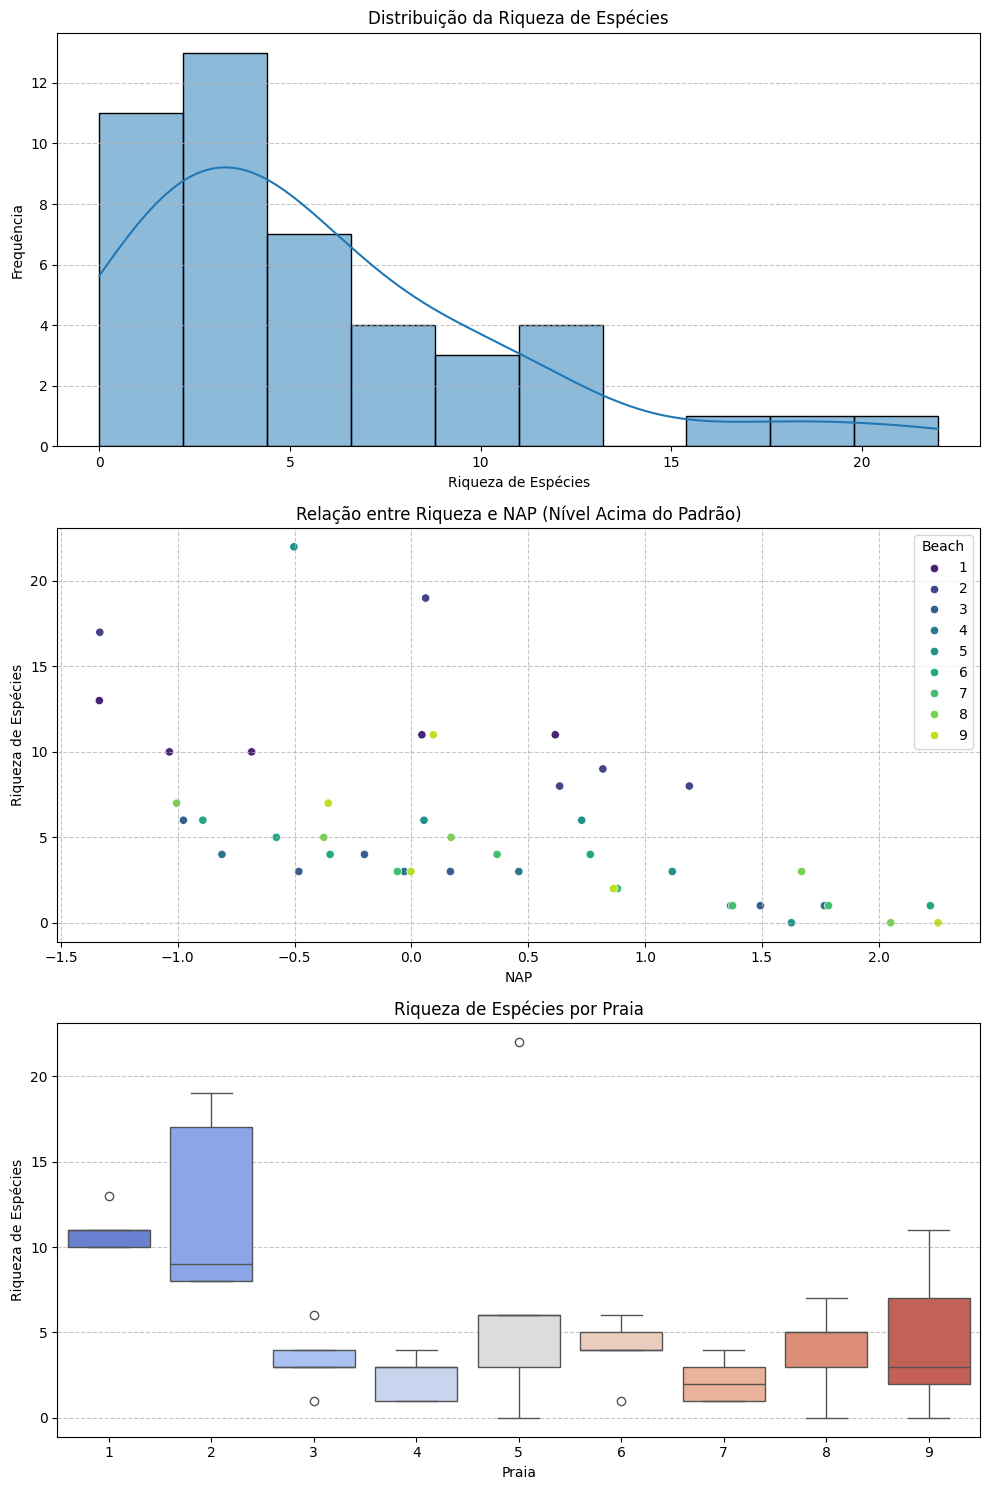

In [2]:
# Converte a coluna 'Beach' para o tipo categórico, o que é importante para a visualização.
data['Beach'] = data['Beach'].astype('category')

# Cria uma figura com subplots para organizar os gráficos.
# A figura terá 3 linhas e 1 coluna, com um tamanho total de 10x15 polegadas.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

# Plot 1: Histograma da Riqueza de Espécies
# Este gráfico mostra a distribuição da variável 'Richness'.
sns.histplot(data=data, x='Richness', bins=10, kde=True, ax=axes[0])
axes[0].set_title('Distribuição da Riqueza de Espécies')
axes[0].set_xlabel('Riqueza de Espécies')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Gráfico de Dispersão da Riqueza versus NAP
# Mostra a relação entre as variáveis 'Richness' e 'NAP', com cada ponto
# colorido de acordo com a 'Beach'.
sns.scatterplot(data=data, x='NAP', y='Richness', hue='Beach', palette='viridis', ax=axes[1])
axes[1].set_title('Relação entre Riqueza e NAP (Nível Acima do Padrão)')
axes[1].set_xlabel('NAP')
axes[1].set_ylabel('Riqueza de Espécies')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Box Plot da Riqueza por Praia
# Compara a distribuição da 'Richness' entre as diferentes 'Beach'.
sns.boxplot(data=data, x='Beach', y='Richness', palette='coolwarm', ax=axes[2])
axes[2].set_title('Riqueza de Espécies por Praia')
axes[2].set_xlabel('Praia')
axes[2].set_ylabel('Riqueza de Espécies')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Ajusta o layout para evitar sobreposição de títulos e rótulos.
plt.tight_layout()

# Salva a figura como um arquivo PNG.
plt.savefig('analise_grafica.png')

# O comando plt.show() não é utilizado para garantir que o script possa ser
# executado de forma não interativa, por exemplo, em servidores.
# plt.show()